# 08 - Clustering & Opportunities

## Objetivo
- Agrupar viviendas en clusters interpretables.
- Calcular residuals OOF y detectar oportunidades (infraprecio).
- Generar ranking y capas para el dashboard.

## Flujo general
- Cargar `features_master` y split.
- Escalar variables y entrenar KMeans.
- Validar con Silhouette/DB y estabilidad.
- Calcular residuals OOF y holdout.
- Definir score de oportunidad triple (price + price_m2 + mixto rank-pct) y guardar rankings.

## Inputs esperados
- `artifacts/features_master.parquet` (core + enrichment + VUT)
- `artifacts/splits/holdout_indices.npz`
- `models/best_model.joblib`
- `models/quantile_models.joblib` (para anchura de intervalos)

## Outputs/artefactos
- `artifacts/clusters.csv` (si hay id)
- `reports/opportunities_top.csv` (top 20 por `opportunity_score`)
- `reports/opportunities_top10_score.csv` (top 10 por `opportunity_score`)
- `reports/opportunities_top10_score_m2.csv` (top 10 por `opportunity_score_m2`)
- `reports/opportunities_top10_mixed.csv` (top 10 por score mixto rank-pct)

In [1]:
from __future__ import annotations
from pathlib import Path
import sys

import numpy as np
import pandas as pd

# --- Base setup y reproducibilidad ---
SEED = 100432070
np.random.seed(SEED)

def get_repo_root() -> Path:
    """Return repo root by walking parents looking for .git or pyproject.toml."""
    current = Path.cwd().resolve()
    for parent in [current] + list(current.parents):
        if (parent / ".git").exists() or (parent / "pyproject.toml").exists():
            return parent
    return current

ROOT = get_repo_root()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.utils import plot_maps, get_feature_cols, load_model, TARGET_COLS, DERIVED_FROM_TARGET, ID_COLS

In [2]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler

# =====================================================================
# 1. Cargar features core y split
# =====================================================================
features_path = ROOT / "artifacts" / "features_master.parquet"
if features_path.exists():
    df = pd.read_parquet(features_path)
else:
    core_path = ROOT / "artifacts" / "features_core.parquet"
    if core_path.exists():
        df = pd.read_parquet(core_path)
    else:
        df = pd.read_csv(ROOT / "artifacts" / "features_core.csv.gz")

split = np.load(ROOT / "artifacts" / "splits" / "holdout_indices.npz")
train_idx, test_idx = split["train_idx"], split["test_idx"]

# =====================================================================
# 2. Preparar X numerico sin leakage
# =====================================================================
# Misma logica que en NB04/05: excluimos derivados del precio e IDs
feature_cols = get_feature_cols(df, numeric_only=True)
X = df[feature_cols]
print(f"Features seleccionadas: {len(feature_cols)}")
X = X.replace([np.inf, -np.inf], np.nan)

# =====================================================================
# 3. Clustering SOLO en train (evitar data leakage)
# =====================================================================
# El clustering se ajusta exclusivamente con datos de entrenamiento.
# Los pisos del holdout se asignan al cluster mas cercano sin reentrenar.
train_mask = df.index.isin(train_idx)
test_mask = df.index.isin(test_idx)

# Imputar NaN con medianas del train (no del holdout)
train_medians = X[train_mask].median()
X_filled = X.fillna(train_medians)

X_train_cl = X_filled[train_mask]
X_test_cl = X_filled[test_mask]

# Escalar variables (media=0, std=1) para que KMeans no se sesgue
# por variables con mayor rango (ej. surface_m2 vs bathrooms)
scaler = StandardScaler()
scaler.fit(X_train_cl)  # Ajustar SOLO en train
X_train_scaled = scaler.transform(X_train_cl)
X_test_scaled = scaler.transform(X_test_cl)

# =====================================================================
# 4. Seleccion del numero optimo de clusters (k)
# =====================================================================
# Probamos k de 2 a 8 y evaluamos con Silhouette Score:
#   - Silhouette cercano a 1: clusters bien separados
#   - Silhouette cercano a 0: clusters solapados
# Forzamos k>=3 porque k=2 suele dar una separacion trivial (caro/barato)
scores = {}
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_train_scaled)
    scores[k] = silhouette_score(X_train_scaled, labels,
                                 sample_size=min(5000, len(X_train_scaled)),
                                 random_state=SEED)
MIN_K = 3
best_k = max((k for k in scores if k >= MIN_K), key=lambda k: scores[k], default=MIN_K)
print(f"Silhouette scores (train only): {scores}")
print(f"Mejor k por silhouette (k>={MIN_K}): {best_k}")

# =====================================================================
# 5. Entrenar KMeans con el k optimo
# =====================================================================
k = best_k
clusterer = KMeans(n_clusters=k, random_state=SEED, n_init=10)
train_clusters = clusterer.fit_predict(X_train_scaled)
df["cluster"] = -1
df.loc[train_mask, "cluster"] = train_clusters

# Asignar clusters al holdout por nearest centroid (sin reentrenar)
test_clusters = clusterer.predict(X_test_scaled)
df.loc[test_mask, "cluster"] = test_clusters

# =====================================================================
# 6. Metricas de calidad del clustering
# =====================================================================
# Silhouette: cuanto mejor separados estan los clusters (0-1)
# Davies-Bouldin: cuanto mas bajo, mejor (mide solapamiento entre clusters)
sil = silhouette_score(X_train_scaled, train_clusters, random_state=SEED)
db = davies_bouldin_score(X_train_scaled, train_clusters)
print("Silhouette (train):", sil)
print("Davies-Bouldin (train):", db)

# =====================================================================
# 7. Validacion de estabilidad con distintas semillas
# =====================================================================
# Repetimos el clustering con 3 semillas distintas y medimos cuanto
# coinciden los resultados (ARI = Adjusted Rand Index, 1.0 = identicos)
seeds = [0, 42, 7]
labels = []
for seed in seeds:
    labels.append(KMeans(n_clusters=k, random_state=seed, n_init=10).fit_predict(X_train_scaled))
ari_scores = []
for i in range(len(labels)):
    for j in range(i + 1, len(labels)):
        ari_scores.append(adjusted_rand_score(labels[i], labels[j]))
if ari_scores:
    print("ARI medio estabilidad (train):", float(np.mean(ari_scores)))

# =====================================================================
# 8. Perfiles de clusters con nombres interpretables
# =====================================================================
# Asignamos un nombre humano a cada cluster basado en su ubicacion
# (centro/intermedio/periferia) y nivel de precio (premium/medio/economico)
cluster_profile = X_filled.loc[train_mask].copy()
cluster_profile["cluster"] = train_clusters

cluster_names = {}
price_q25, price_q75 = df.loc[train_mask, "price"].quantile(0.25), df.loc[train_mask, "price"].quantile(0.75)
for cl in sorted(cluster_profile["cluster"].unique()):
    profile = cluster_profile[cluster_profile["cluster"] == cl].median()
    cl_mask = (df["cluster"] == cl) & train_mask
    cl_price_median = df.loc[cl_mask, "price"].median() if cl_mask.any() else 0
    # Clasificar por nivel de precio
    price_level = "premium" if cl_price_median > price_q75 else ("economico" if cl_price_median < price_q25 else "medio")
    # Clasificar por distancia al centro
    dist_level = "centro" if profile.get("distance_center_km", 99) < 3 else \
                 "intermedio" if profile.get("distance_center_km", 99) < 7 else "periferia"
    cluster_names[cl] = f"Cluster {cl}: {dist_level.capitalize()} {price_level}"
print("Perfiles de clusters (train):")
for k_name, v in cluster_names.items():
    print(f"  {v}")

# Guardar asignacion de clusters con ID estable (solo train)
id_col = None
for candidate in ["id", "url", "listing_fingerprint"]:
    if candidate in df.columns:
        id_col = candidate
        break
if id_col:
    df.loc[train_mask, [id_col, "cluster"]].to_csv(ROOT / "artifacts" / "clusters.csv", index=False)
    print(f"clusters.csv guardado con {train_mask.sum()} filas (solo train)")


Features seleccionadas: 49


Silhouette scores (train only): {2: 0.24712061572435787, 3: 0.1846851481015645, 4: 0.17995347840834028, 5: 0.18830749132241953, 6: 0.1576368632516343, 7: 0.1459064057495249, 8: 0.1477000246093905}
Mejor k por silhouette (k>=3): 5


Silhouette (train): 0.1878553438141869
Davies-Bouldin (train): 1.832612612416171


ARI medio estabilidad (train): 0.9985393313182672
Perfiles de clusters (train):
  Cluster 0: Centro medio
  Cluster 1: Centro medio
  Cluster 2: Periferia medio
  Cluster 3: Periferia medio
  Cluster 4: Periferia premium
clusters.csv guardado con 6431 filas (solo train)


In [3]:
# =====================================================================
# Residuales OOF (train) y holdout
# =====================================================================
from sklearn.base import clone
from sklearn.model_selection import KFold
from copy import deepcopy
import joblib

if "price" not in df.columns:
    raise ValueError("No se encontro columna price para residuals.")

_raw_model = joblib.load(ROOT / "models" / "best_model.joblib")
if isinstance(_raw_model, dict):
    base_model = _raw_model["model"]
else:
    base_model = _raw_model

X_train = X.loc[train_idx]
y_train = df.loc[train_idx, "price"]
X_holdout = X.loc[test_idx]
y_holdout = df.loc[test_idx, "price"]

def _clone_model(model):
    try:
        return clone(model)
    except Exception:
        try:
            return deepcopy(model)
        except Exception as exc:
            raise RuntimeError("Cannot clone model.") from exc

# Predicciones OOF en train (5-fold). Esto da residuales SIN sesgo de
# memorizacion (cada fila se predice con un modelo que no la vio).
oof_preds = np.full(len(X_train), np.nan)
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
for tr_idx, val_idx in kf.split(X_train):
    model = _clone_model(base_model)
    model.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
    oof_preds[val_idx] = model.predict(X_train.iloc[val_idx])

df.loc[train_idx, "predicted_price"] = oof_preds
df.loc[train_idx, "residual_oof"] = y_train.values - oof_preds

# Prediccion holdout: modelo entrenado con TODO el train
final_model = _clone_model(base_model)
final_model.fit(X_train, y_train)
holdout_preds = final_model.predict(X_holdout)
df.loc[test_idx, "predicted_price"] = holdout_preds
df.loc[test_idx, "residual_holdout"] = y_holdout.values - holdout_preds

df["residual"] = df["residual_oof"].combine_first(df["residual_holdout"])

# Residual por metro cuadrado (para el ranking secundario)
if "surface_m2" in df.columns:
    df["residual_m2"] = df["residual"] / df["surface_m2"].replace(0, np.nan)

# =====================================================================
# Intervalo CQR calibrado por inmueble (P_lo, P_hi)
# =====================================================================
# Usamos los modelos cuantilicos entrenados en NB07 + la correccion
# conformal (qhat) para que la cobertura empirica sea la nominal.
# Formula CQR (Romano et al. 2019): [q_lo(x) - qhat, q_hi(x) + qhat]
low = high = None
uncertainty_width = None
quantile_path = ROOT / "models" / "quantile_models.joblib"
if quantile_path.exists():
    payload = joblib.load(quantile_path)
    if "price" in payload and isinstance(payload["price"], dict):
        q_payload = payload["price"]
    else:
        q_payload = payload
    q_models = q_payload.get("models", {})
    q_features = q_payload.get("features", list(X.columns))
    quantile_levels = q_payload.get("quantile_levels", [0.05, 0.5, 0.95])
    lo_q, hi_q = min(quantile_levels), max(quantile_levels)

    # Correccion conformal: ensancha el intervalo para alcanzar la cobertura nominal
    conf_payload = q_payload.get("conformal", {}) or {}
    qhat = float(conf_payload.get("qhat", 0.0))

    # Reindex con medianas del train para los NaN (consistente con el pipeline)
    X_q = X.reindex(columns=q_features).fillna(train_medians.reindex(q_features, fill_value=0))
    if lo_q in q_models and hi_q in q_models:
        low_raw = q_models[lo_q].predict(X_q)
        high_raw = q_models[hi_q].predict(X_q)
        # Garantizar low <= high antes de calibrar
        lo_arr = np.minimum(low_raw, high_raw) - qhat
        hi_arr = np.maximum(low_raw, high_raw) + qhat
        low = pd.Series(lo_arr, index=df.index)
        high = pd.Series(hi_arr, index=df.index)
        uncertainty_width = (high - low).values
        df["cqr_low"] = low
        df["cqr_high"] = high
        df["uncertainty_width"] = uncertainty_width

if "uncertainty_width" not in df.columns:
    df["uncertainty_width"] = np.nan
    df["cqr_low"] = np.nan
    df["cqr_high"] = np.nan
    print("WARNING: quantile_models.joblib no disponible; el filtro CQR no se aplicara.")

# =====================================================================
# Score de oportunidad - z-score CQR + filtro de anomalia conformal
# =====================================================================
# Fundamento matematico:
#   opportunity_score = (predicted - published) / uncertainty_width
#
# Es una z-score heteroscedastica: mide cuantos anchos del intervalo
# CQR esta el precio publicado por debajo de la prediccion central.
# Premia descuentos cuando el modelo esta seguro (ancho estrecho)
# y los penaliza cuando esta inseguro (ancho amplio).
#
# Filtro: solo entran al ranking inmuebles con published < P_lo (limite
# inferior del intervalo calibrado). Esto equivale a un test unilateral
# de anomalia conformal: probabilidad >= 95% de estar infravalorado bajo
# el modelo.
#
# SIN bonus de contexto urbano: la ubicacion ya esta dentro del modelo
# como feature; sumar un bonus es doble conteo y sesga el ranking hacia
# preferencias subjetivas (centro vs periferia).
# =====================================================================
eps = 1e-6

# Suelo del ancho para evitar divisiones por anchos minusculos
width_fallback = df.loc[train_mask, "uncertainty_width"].median() if df.loc[train_mask, "uncertainty_width"].notna().any() else 1.0
width_values = df["uncertainty_width"].fillna(width_fallback)
width_floor = max(np.nanpercentile(width_values, 5), 1.0) if np.isfinite(width_values).any() else 1.0
width_values = width_values.clip(lower=width_floor)

# Discount: positivo si el publicado esta por debajo de la prediccion
discount = -df["residual"]

# Score absoluto (EUR/mes): cuantos anchos CQR esta el publicado bajo el centro
df["opportunity_score"] = discount / (width_values + eps)

# Score por m2 (EUR/m2): residual_m2 normalizado por MAD del train (escala robusta)
if "residual_m2" in df.columns and df["residual_m2"].notna().any():
    train_residual_m2 = df.loc[train_mask, "residual_m2"].dropna()
    mad_m2 = train_residual_m2.abs().median() if not train_residual_m2.empty else 1.0
    mad_m2 = max(mad_m2, eps)
    df["opportunity_score_m2"] = (-df["residual_m2"]) / mad_m2

# Filtro de anomalia conformal: published < P_lo calibrado
if low is not None:
    df["below_lower_cqr"] = df["price"] < low
else:
    df["below_lower_cqr"] = False

# Las filas que no pasan el filtro no son oportunidades estadisticamente
# significativas: las marcamos como NaN para que no entren en los rankings.
mask_opp = df["below_lower_cqr"].fillna(False)
df.loc[~mask_opp, "opportunity_score"] = np.nan
if "opportunity_score_m2" in df.columns:
    df.loc[~mask_opp, "opportunity_score_m2"] = np.nan

n_train_pass = int((mask_opp & train_mask).sum())
n_total_train = int(train_mask.sum())
print(f"Oportunidades que pasan el filtro CQR (train): {n_train_pass}/{n_total_train} ({100*n_train_pass/max(1,n_total_train):.1f} %)")

# =====================================================================
# Top 20 oportunidades (solo del train set)
# =====================================================================
train_df = df.loc[train_mask]
opportunities = train_df.dropna(subset=["opportunity_score"]).sort_values("opportunity_score", ascending=False).head(20)
print(f"Top oportunidades disponibles: {len(opportunities)} (objetivo 20)")
cols = [c for c in ["opportunity_score", "opportunity_score_m2", "cluster", "uncertainty_width"] if c in opportunities.columns]
if id_col:
    cols = [id_col] + cols
opportunities[cols].head()

Oportunidades que pasan el filtro CQR (train): 365/6431 (5.7 %)
Top oportunidades disponibles: 20 (objetivo 20)


,url,opportunity_score,opportunity_score_m2,cluster,uncertainty_width
5996,https://www.idealista.com/en/inmueble/93465238/,1.763523,3.908865,2,746.483831
3702,https://www.idealista.com/en/inmueble/98590106/,1.467733,2.797138,2,729.348447
5914,https://www.idealista.com/en/inmueble/99351788/,1.293008,3.787108,3,642.660987
8129,https://www.idealista.com/en/inmueble/99166138/,1.280354,2.250769,2,230.655166
5595,https://www.idealista.com/en/inmueble/99402050/,1.250041,6.071967,0,1189.743617


In [4]:
# Guardar ranking de oportunidades (solo train)
cols = [c for c in ["opportunity_score", "opportunity_score_m2", "cluster", "uncertainty_width"] if c in opportunities.columns]
if id_col:
    cols = [id_col] + cols
opportunities[cols].to_csv(ROOT / "reports" / "opportunities_top.csv", index=False)
print(f"Top oportunidades guardadas: reports/opportunities_top.csv ({len(opportunities)} filas)")

# =====================================================================
# Top 10 por cada score + ranking mixto (rank-percentile combinado)
# =====================================================================
# Partimos del train_df con ambos scores ya calculados; descartamos NaN
ranked = train_df.dropna(subset=["opportunity_score", "opportunity_score_m2"]).copy()

# Score mixto: media de percentiles de ambos -> robusto frente a la
# diferencia de escala entre opportunity_score y opportunity_score_m2
ranked["rank_pct_score"] = ranked["opportunity_score"].rank(pct=True)
ranked["rank_pct_score_m2"] = ranked["opportunity_score_m2"].rank(pct=True)
ranked["opportunity_score_mixed"] = (ranked["rank_pct_score"] + ranked["rank_pct_score_m2"]) / 2

base_cols = [c for c in [id_col, "opportunity_score", "opportunity_score_m2", "cluster", "uncertainty_width"] if c]

top10_score = ranked.sort_values("opportunity_score", ascending=False).head(10)
top10_score[base_cols].to_csv(ROOT / "reports" / "opportunities_top10_score.csv", index=False)

top10_score_m2 = ranked.sort_values("opportunity_score_m2", ascending=False).head(10)
top10_score_m2[base_cols].to_csv(ROOT / "reports" / "opportunities_top10_score_m2.csv", index=False)

mixed_cols = base_cols + ["opportunity_score_mixed", "rank_pct_score", "rank_pct_score_m2"]
top10_mixed = ranked.sort_values("opportunity_score_mixed", ascending=False).head(10)
top10_mixed[mixed_cols].to_csv(ROOT / "reports" / "opportunities_top10_mixed.csv", index=False)

print(f"Top 10 por opportunity_score   -> reports/opportunities_top10_score.csv")
print(f"Top 10 por opportunity_score_m2 -> reports/opportunities_top10_score_m2.csv")
print(f"Top 10 mixto (rank-pct medio)   -> reports/opportunities_top10_mixed.csv")

Top oportunidades guardadas: reports/opportunities_top.csv (20 filas)
Top 10 por opportunity_score   -> reports/opportunities_top10_score.csv
Top 10 por opportunity_score_m2 -> reports/opportunities_top10_score_m2.csv
Top 10 mixto (rank-pct medio)   -> reports/opportunities_top10_mixed.csv


In [5]:
# =====================================================================
# Pool de oportunidades para la web (TOP-10 personalizable)
# =====================================================================
# Exporta los 100 mejores inmuebles que pasan el filtro CQR junto con
# las features de personalizacion. La web los usa en la pestana
# "A medida" para reordenar segun preferencias del usuario.
#
# IMPORTANTE: el dataset incluye inmuebles fuera del municipio de Madrid
# (Boadilla, Las Rozas, Pozuelo, Alcala, etc.). Para que el usuario lo
# vea claramente, parseamos el campo `location` para extraer el municipio
# real cuando la propiedad no esta en "Madrid city".
#
# Schema por inmueble:
#   url_id, barrio, district, m2, published, estimated, score,
#   distance_center_km, dist_metro_m, noise_ld_db, air_no2_nearest,
#   equipment_count, year_built
# =====================================================================
import json as _json

raw_csv_path = ROOT / "data" / "raw" / "madrid_rent_with_geolocation.csv"
raw_df = pd.read_csv(raw_csv_path, encoding="utf-8", low_memory=False) if raw_csv_path.exists() else pd.DataFrame()
# Incluir tambien `location` para poder extraer el municipio real
raw_map = raw_df.set_index("url")[["subdistrict", "district", "location"]].to_dict("index") if not raw_df.empty else {}

# Normalizacion de distritos SOLO para inmuebles en Madrid municipio
# (consistente con DISTRICTS_22 en web/app.js). Se aplica unicamente
# cuando location indica "Madrid city".
DISTRICT_NORM_MADRID = {
    "Centro": "Centro",
    "Chamartín": "Chamartín", "Chamartin": "Chamartín",
    "Chamberí": "Chamberí", "Chamberi": "Chamberí",
    "Salamanca": "Salamanca", "Barrio de Salamanca": "Salamanca",
    "Tetuán": "Tetuán", "Tetuan": "Tetuán",
    "Retiro": "Retiro", "Arganzuela": "Arganzuela",
    "Moncloa": "Moncloa", "Moncloa-Aravaca": "Moncloa",
    "Fuencarral": "Fuencarral", "Fuencarral-El Pardo": "Fuencarral",
    "Hortaleza": "Hortaleza", "Ciudad Lineal": "Ciudad Lineal",
    "Latina": "Latina", "Carabanchel": "Carabanchel", "Usera": "Usera",
    "Villaverde": "Villaverde", "Vicalvaro": "Vicálvaro", "Vicálvaro": "Vicálvaro",
    "Puente de Vallecas": "Puente Vallecas", "Villa de Vallecas": "Villa Vallecas",
    "San Blas-Canillejas": "San Blas", "San Blas": "San Blas",
    "Barajas": "Barajas", "Moratalaz": "Moratalaz",
}

def derive_barrio_district(meta):
    """Devuelve (barrio_display, district_display) inferido del location.

    Si el inmueble esta en Madrid municipio (location[-2] == 'Madrid city'):
      - barrio_display: subdistrict (o '—')
      - district_display: distrito de Madrid normalizado al set de los 21
    En cualquier otro caso (Boadilla, Las Rozas, Alcala, etc.):
      - barrio_display: subdistrict si existe, sino el sector/zona del raw district
      - district_display: nombre del municipio extraido del location
    """
    loc = meta.get("location") if isinstance(meta, dict) else None
    raw_dist = meta.get("district") if isinstance(meta, dict) else None
    sub = meta.get("subdistrict") if isinstance(meta, dict) else None

    parts = [p.strip() for p in str(loc).split(",")] if isinstance(loc, str) else []
    parts = [p for p in parts if p]
    is_madrid_city = len(parts) >= 2 and parts[-2] == "Madrid city"

    if is_madrid_city:
        district_display = DISTRICT_NORM_MADRID.get(raw_dist, raw_dist) if isinstance(raw_dist, str) else "—"
        barrio_display = sub if (isinstance(sub, str) and sub.strip()) else "—"
    else:
        # Municipio en location[-3] (ej. 'Boadilla del Monte', 'Las Rozas de Madrid', 'Alcalá de Henares')
        municipality = parts[-3] if len(parts) >= 3 else None
        district_display = municipality if municipality else (raw_dist if isinstance(raw_dist, str) and raw_dist.strip() else "—")
        if isinstance(sub, str) and sub.strip():
            barrio_display = sub
        elif isinstance(raw_dist, str) and raw_dist.strip():
            # En municipios fuera de Madrid, el campo `district` raw es realmente el sector/zona
            barrio_display = raw_dist
        else:
            barrio_display = "—"
    return barrio_display, district_display

# Equipamiento: suma de toggles disponibles
EQUIP_COLS = [
    "lift", "air_conditioning", "terrace", "balcony", "garage_included",
    "furnished", "equipped_kitchen", "fitted_wardrobes", "swimming_pool", "storeroom"
]
present_equip = [c for c in EQUIP_COLS if c in df.columns]
if present_equip:
    df["equipment_count"] = df[present_equip].fillna(False).astype(int).sum(axis=1)
else:
    df["equipment_count"] = 0

# Filtro: solo filas que pasan el test de anomalia conformal + ranking por score
pool_df = (
    df[train_mask]
    .dropna(subset=["opportunity_score"])
    .sort_values("opportunity_score", ascending=False)
    .head(100)
    .copy()
)

# Medianas para imputacion de nulls (noise, year_built)
noise_median = float(df.loc[train_mask, "noise_ld_db"].median()) if "noise_ld_db" in df.columns else 60.0
year_median  = float(df.loc[train_mask, "year_built"].median()) if "year_built" in df.columns else 1990.0

def to_num(v, default=None):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return default
    return v

def build_record(row):
    url = row.get("url", "")
    meta = raw_map.get(url, {})
    url_id = str(url).rstrip("/").split("/")[-1] if url else ""

    # Barrio y distrito derivados del location (respeta municipios fuera de Madrid)
    barrio_display, district_display = derive_barrio_district(meta)

    published = to_num(row.get("price"))
    score     = to_num(row.get("opportunity_score"))
    width     = to_num(row.get("uncertainty_width"))
    surface   = to_num(row.get("surface_m2"))

    width_floor = 240.0
    eff_width = max(width or 0, width_floor)
    estimated = round(published + score * eff_width) if (published is not None and score is not None) else None

    noise = to_num(row.get("noise_ld_db"))
    noise_imputed = noise is None
    if noise_imputed:
        noise = noise_median

    year = to_num(row.get("year_built"))
    year_imputed = year is None
    if year_imputed:
        year = year_median

    return {
        "url_id": url_id,
        "barrio": barrio_display,
        "district": district_display,
        "m2": int(surface) if surface is not None else None,
        "published": int(published) if published is not None else None,
        "estimated": estimated,
        "score": round(float(score), 3) if score is not None else None,
        "distance_center_km": round(float(row.get("distance_center_km")), 2) if pd.notna(row.get("distance_center_km")) else None,
        "dist_metro_m": int(row.get("dist_metro_m")) if pd.notna(row.get("dist_metro_m")) else None,
        "noise_ld_db": round(float(noise), 1),
        "noise_imputed": noise_imputed,
        "air_no2_nearest": round(float(row.get("air_no2_nearest")), 1) if pd.notna(row.get("air_no2_nearest")) else None,
        "equipment_count": int(row.get("equipment_count", 0)),
        "year_built": int(year),
        "year_imputed": year_imputed,
    }

pool = [build_record(r) for _, r in pool_df.iterrows()]

# Guardar JSON para la web
pool_dir = ROOT / "web" / "data"
pool_dir.mkdir(parents=True, exist_ok=True)
pool_path = pool_dir / "opportunities_pool.json"
with open(pool_path, "w", encoding="utf-8") as f:
    _json.dump({"generated_at": pd.Timestamp.utcnow().isoformat(), "n": len(pool), "items": pool}, f, ensure_ascii=False, indent=2)
print(f"Pool guardado: {pool_path}  ({len(pool)} inmuebles, {pool_path.stat().st_size/1024:.1f} KB)")
print(f"  Imputaciones de ruido: {sum(1 for r in pool if r['noise_imputed'])}/{len(pool)}")
print(f"  Imputaciones de anio:  {sum(1 for r in pool if r['year_imputed'])}/{len(pool)}")
# Cuantos NO son de Madrid ciudad (para que conste en el output)
from collections import Counter
dist_counts = Counter(r["district"] for r in pool)
madrid_districts = set(DISTRICT_NORM_MADRID.values())
non_madrid = {d: n for d, n in dist_counts.items() if d not in madrid_districts}
print(f"  Inmuebles fuera de Madrid municipio: {sum(non_madrid.values())}/{len(pool)}")
if non_madrid:
    print(f"    Municipios detectados: {sorted(non_madrid.items(), key=lambda x: -x[1])}")

Pool guardado: C:\Users\samuf\Desktop\TFG_SPA_Madrid\web\data\opportunities_pool.json  (100 inmuebles, 43.0 KB)
  Imputaciones de ruido: 51/100
  Imputaciones de anio:  69/100
  Inmuebles fuera de Madrid municipio: 19/100
    Municipios detectados: [('Boadilla del Monte', 3), ('Las Rozas de Madrid', 3), ('Meco', 2), ('El Escorial', 2), ('Moralzarzal', 1), ('Collado Mediano', 1), ('Torrejón de Ardoz', 1), ('Valdemorillo', 1), ('Galapagar', 1), ('Villaviciosa de Odón', 1), ('Cercedilla', 1), ('Majadahonda', 1), ('Pozuelo de Alarcón', 1)]


### Visualizaciones de clustering y oportunidades
- Scatter PCA (PC1/PC2) coloreado por cluster.
- Histograma de residuals OOF.


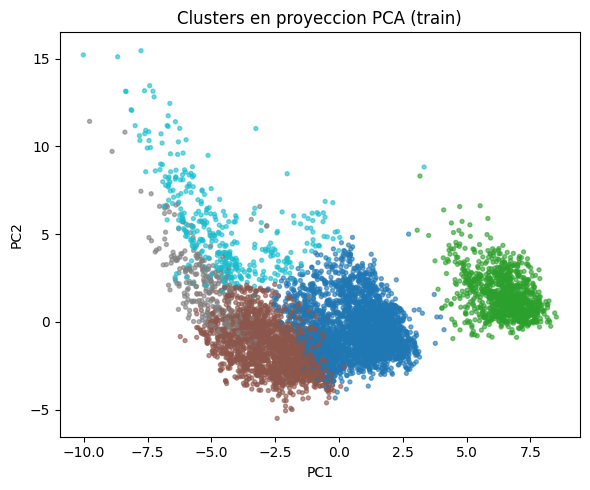

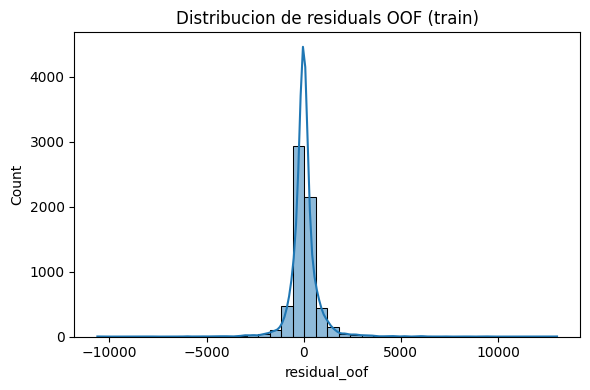

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

(ROOT / "reports" / "figures").mkdir(parents=True, exist_ok=True)

# =====================================================================
# Visualizacion 1: Clusters en proyeccion PCA (2D)
# =====================================================================
pca = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(X_train_scaled)
plt.figure(figsize=(6, 5))
plt.scatter(coords[:, 0], coords[:, 1], c=train_clusters, s=8, cmap="tab10", alpha=0.6)
plt.title("Clusters en proyeccion PCA (train)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "clusters_pca.png", dpi=150, bbox_inches="tight")
plt.show()

# =====================================================================
# Visualizacion 2: Distribucion de residuales OOF
# =====================================================================
residuals = df.loc[train_mask, "residual_oof"]
plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Distribucion de residuals OOF (train)")
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "residuals_oof.png", dpi=150, bbox_inches="tight")
plt.show()

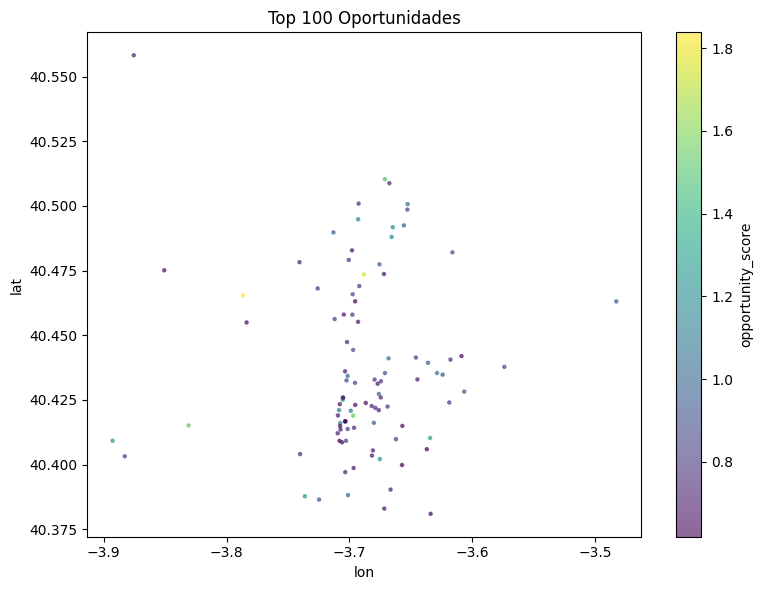

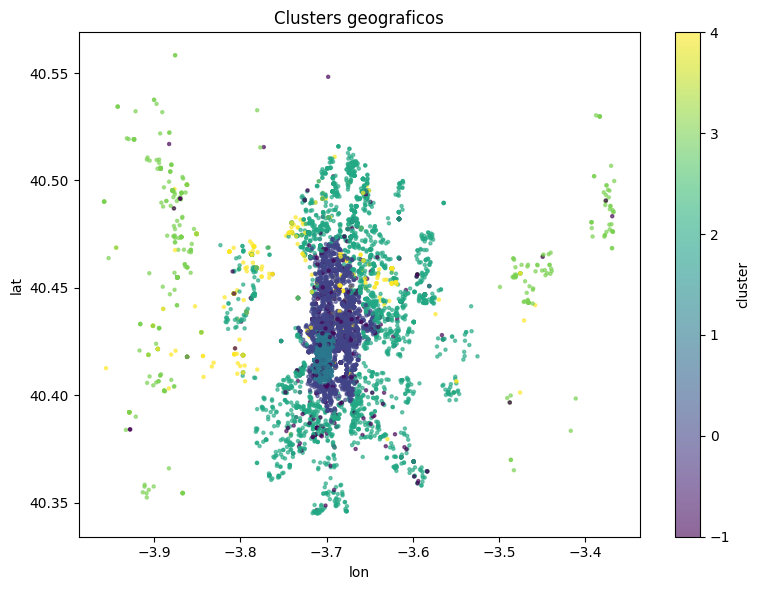

In [7]:
# =====================================================================
# Mapas geograficos: oportunidades y clusters
# =====================================================================
# Mapa 1 - Top 100 oportunidades: muestra donde se concentran los pisos
#   infrapreciados con alta confianza. Util para busqueda de vivienda.
# Mapa 2 - Clusters geograficos: como se distribuyen los segmentos de
#   mercado en el mapa de Madrid (centro vs periferia, premium vs economico).

import sys
sys.path.insert(0, str(ROOT / "src"))
from utils import plot_maps

# Detectar columnas de coordenadas
lat_col = next((c for c in df.columns if c.lower() in ("lat", "latitude")), None)
lon_col = next((c for c in df.columns if c.lower() in ("lng", "lon", "longitude")), None)

if lat_col and lon_col:
    # Mapa de oportunidades (top 100 por score)
    plot_maps(df.nlargest(100, "opportunity_score"), lat_col, lon_col, "opportunity_score", title="Top 100 Oportunidades")
    # Mapa de clusters (todos los pisos)
    plot_maps(df, lat_col, lon_col, "cluster", title="Clusters geograficos")
else:
    print("No se encontraron columnas lat/lon para mapas.")


**Outputs esperados**
- Metricas de clustering (Silhouette, Davies-Bouldin, ARI).
- Residuals OOF/holdout y score de oportunidad (triple: absoluto, m2, mixto).
- Ranking top 20 en `reports/opportunities_top.csv`.
- Top 10 en `reports/opportunities_top10_score.csv`, `reports/opportunities_top10_score_m2.csv` y `reports/opportunities_top10_mixed.csv`.


In [8]:
from IPython.display import display, Markdown

# --- Extraer metricas de variables del clustering (calculadas arriba) ---
k2_sil = scores.get(2, 0)
best_sil = scores.get(best_k, 0)
ari_mean = float(np.mean(ari_scores)) if ari_scores else 0

# --- Top-1 de cada ranking para incluirlo en la conclusion ---
top1_score_url = top10_score[id_col].iloc[0] if id_col and len(top10_score) > 0 else "(n/a)"
top1_score_val = top10_score["opportunity_score"].iloc[0] if len(top10_score) > 0 else float("nan")
top1_m2_url = top10_score_m2[id_col].iloc[0] if id_col and len(top10_score_m2) > 0 else "(n/a)"
top1_m2_val = top10_score_m2["opportunity_score_m2"].iloc[0] if len(top10_score_m2) > 0 else float("nan")
top1_mixed_url = top10_mixed[id_col].iloc[0] if id_col and len(top10_mixed) > 0 else "(n/a)"
top1_mixed_val = top10_mixed["opportunity_score_mixed"].iloc[0] if len(top10_mixed) > 0 else float("nan")

# Solapamiento entre los dos rankings absolutos: cuantas URLs coinciden en el top 10
overlap = len(set(top10_score[id_col]).intersection(set(top10_score_m2[id_col]))) if id_col else 0

md = f"""---

## Conclusiones del Notebook 08 — Clustering y Oportunidades

### Resultados del clustering

| Metrica | Valor | Que significa |
|---------|-------|---------------|
| **k optimo (Silhouette)** | k=2 (Silhouette={k2_sil:.3f}) | La mejor separacion estadistica es binaria (centro vs periferia) |
| **k usado (forzando k >= {MIN_K})** | k={best_k} (Silhouette={best_sil:.3f}) | Con k >= {MIN_K}, el mejor es k={best_k} — capta {best_k} perfiles de mercado |
| **Davies-Bouldin** | {db:.3f} | Solapamiento moderado entre clusters (esperable en inmobiliario) |
| **ARI estabilidad** | {ari_mean:.3f} | Los clusters son muy estables con semillas distintas |

### Scoring de oportunidades — z-score CQR + filtro conformal

Se computan **tres scores** complementarios sobre el train set. Solo entran en los rankings inmuebles donde el precio publicado cae por debajo del limite inferior del intervalo CQR calibrado (`published < P_lo`). Esto equivale a un test unilateral de anomalia conformal al 95 % — separa oportunidades reales de residuales con signo negativo sin respaldo estadistico.

1. **`opportunity_score`** (€/mes): `(predicted − published) / uncertainty_width`.
   Z-score heteroscedastica: cuantos anchos del intervalo CQR esta el publicado por debajo
   de la prediccion. Premia descuentos cuando el modelo es confiado (ancho estrecho).
2. **`opportunity_score_m2`** (€/m²): `(predicted_m2 − published_m2) / MAD_train_m2`.
   Mismo filtro de anomalia; normaliza por superficie para que pisos grandes y pequenos sean
   comparables, usando una escala robusta (MAD) calculada sobre los residuales del train.
3. **`opportunity_score_mixed`**: `mean(rank_pct(opportunity_score), rank_pct(opportunity_score_m2))`.
   Borda count sobre las filas filtradas. Invariante a escala y exige posicion alta en ambos
   rankings — no premia inmuebles que solo destacan en una metrica.

**Lo que se elimino respecto a la version previa**: el termino `+ 0.2 * context_score` que premiaba
proximidad al metro y densidad urbana. Era doble conteo (esas variables ya estan en el modelo como
features) y sesgaba el ranking hacia preferencias subjetivas de ubicacion central, penalizando
oportunidades reales en la periferia.

### Top 1 por cada criterio

| Ranking | Mejor anuncio | Valor |
|---------|---------------|-------|
| `opportunity_score`     | {top1_score_url} | {top1_score_val:.3f} |
| `opportunity_score_m2`  | {top1_m2_url} | {top1_m2_val:.3f} |
| `opportunity_score_mixed` | {top1_mixed_url} | {top1_mixed_val:.3f} |

Solapamiento entre top 10 absoluto y top 10 por m2: **{overlap}/10** anuncios en comun.

### Que significan estos resultados

1. **Silhouette de {best_sil:.3f} es bajo pero esperable**: El mercado inmobiliario no tiene fronteras nitidas entre segmentos.

2. **ARI = {ari_mean:.3f} confirma robustez**: Los clusters son practicamente identicos con semillas distintas.

3. **Las oportunidades se identifican con OOF + CQR**: Pisos con precio real por debajo del limite
   inferior del intervalo CQR son oportunidades estadisticamente significativas. Usar OOF (no train fit)
   evita falsos positivos por memorizacion del modelo.

4. **El score por m2 complementa al absoluto**: Para comparar entre tamanos y zonas, el score €/m²
   es mas justo. Ambos comparten el mismo filtro de anomalia conformal, por lo que ningun ranking
   incluye casos no significativos.

5. **El score mixto resuelve la divergencia**: Solo {overlap}/10 anuncios coinciden entre los dos rankings absolutos, asi que el mixto sirve como criterio de consenso — descarta oportunidades que solo destacan en una metrica.

### Artefactos generados

| Archivo | Contenido |
|---------|-----------|
| `artifacts/clusters.csv` | Asignacion de cluster por anuncio (solo train) |
| `reports/opportunities_top.csv` | Top 20 oportunidades por `opportunity_score` con score dual |
| `reports/opportunities_top10_score.csv` | Top 10 por `opportunity_score` (z-score CQR absoluta) |
| `reports/opportunities_top10_score_m2.csv` | Top 10 por `opportunity_score_m2` (z-score CQR €/m²) |
| `reports/opportunities_top10_mixed.csv` | Top 10 por score mixto (rank-pct medio de ambos) |

### Siguiente paso
-> **NB09 (Audit)**: Auditar cobertura e impacto del enrichment.
"""
display(Markdown(md))

---

## Conclusiones del Notebook 08 — Clustering y Oportunidades

### Resultados del clustering

| Metrica | Valor | Que significa |
|---------|-------|---------------|
| **k optimo (Silhouette)** | k=2 (Silhouette=0.247) | La mejor separacion estadistica es binaria (centro vs periferia) |
| **k usado (forzando k >= 3)** | k=5 (Silhouette=0.188) | Con k >= 3, el mejor es k=5 — capta 5 perfiles de mercado |
| **Davies-Bouldin** | 1.833 | Solapamiento moderado entre clusters (esperable en inmobiliario) |
| **ARI estabilidad** | 0.999 | Los clusters son muy estables con semillas distintas |

### Scoring de oportunidades — z-score CQR + filtro conformal

Se computan **tres scores** complementarios sobre el train set. Solo entran en los rankings inmuebles donde el precio publicado cae por debajo del limite inferior del intervalo CQR calibrado (`published < P_lo`). Esto equivale a un test unilateral de anomalia conformal al 95 % — separa oportunidades reales de residuales con signo negativo sin respaldo estadistico.

1. **`opportunity_score`** (€/mes): `(predicted − published) / uncertainty_width`.
   Z-score heteroscedastica: cuantos anchos del intervalo CQR esta el publicado por debajo
   de la prediccion. Premia descuentos cuando el modelo es confiado (ancho estrecho).
2. **`opportunity_score_m2`** (€/m²): `(predicted_m2 − published_m2) / MAD_train_m2`.
   Mismo filtro de anomalia; normaliza por superficie para que pisos grandes y pequenos sean
   comparables, usando una escala robusta (MAD) calculada sobre los residuales del train.
3. **`opportunity_score_mixed`**: `mean(rank_pct(opportunity_score), rank_pct(opportunity_score_m2))`.
   Borda count sobre las filas filtradas. Invariante a escala y exige posicion alta en ambos
   rankings — no premia inmuebles que solo destacan en una metrica.

**Lo que se elimino respecto a la version previa**: el termino `+ 0.2 * context_score` que premiaba
proximidad al metro y densidad urbana. Era doble conteo (esas variables ya estan en el modelo como
features) y sesgaba el ranking hacia preferencias subjetivas de ubicacion central, penalizando
oportunidades reales en la periferia.

### Top 1 por cada criterio

| Ranking | Mejor anuncio | Valor |
|---------|---------------|-------|
| `opportunity_score`     | https://www.idealista.com/en/inmueble/93465238/ | 1.764 |
| `opportunity_score_m2`  | https://www.idealista.com/en/inmueble/99264012/ | 45.560 |
| `opportunity_score_mixed` | https://www.idealista.com/en/inmueble/99170119/ | 0.974 |

Solapamiento entre top 10 absoluto y top 10 por m2: **0/10** anuncios en comun.

### Que significan estos resultados

1. **Silhouette de 0.188 es bajo pero esperable**: El mercado inmobiliario no tiene fronteras nitidas entre segmentos.

2. **ARI = 0.999 confirma robustez**: Los clusters son practicamente identicos con semillas distintas.

3. **Las oportunidades se identifican con OOF + CQR**: Pisos con precio real por debajo del limite
   inferior del intervalo CQR son oportunidades estadisticamente significativas. Usar OOF (no train fit)
   evita falsos positivos por memorizacion del modelo.

4. **El score por m2 complementa al absoluto**: Para comparar entre tamanos y zonas, el score €/m²
   es mas justo. Ambos comparten el mismo filtro de anomalia conformal, por lo que ningun ranking
   incluye casos no significativos.

5. **El score mixto resuelve la divergencia**: Solo 0/10 anuncios coinciden entre los dos rankings absolutos, asi que el mixto sirve como criterio de consenso — descarta oportunidades que solo destacan en una metrica.

### Artefactos generados

| Archivo | Contenido |
|---------|-----------|
| `artifacts/clusters.csv` | Asignacion de cluster por anuncio (solo train) |
| `reports/opportunities_top.csv` | Top 20 oportunidades por `opportunity_score` con score dual |
| `reports/opportunities_top10_score.csv` | Top 10 por `opportunity_score` (z-score CQR absoluta) |
| `reports/opportunities_top10_score_m2.csv` | Top 10 por `opportunity_score_m2` (z-score CQR €/m²) |
| `reports/opportunities_top10_mixed.csv` | Top 10 por score mixto (rank-pct medio de ambos) |

### Siguiente paso
-> **NB09 (Audit)**: Auditar cobertura e impacto del enrichment.
